# BeatAML Tabular Baseline

Notebook runner for the internal BeatAML tabular baseline.

Protocol:
- Train/validation cohort: `Waves1+2`
- Test cohort: `Waves3+4`
- Label: `label_auc100 = auc < 100`
- Models: Random Forest and XGBoost
- Primary metrics: AUROC and balanced accuracy

The reusable training logic lives in `scripts/pipeline/tabular_internal/run.py`. This notebook is the readable pipeline entrypoint.

In [ ]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.pipeline.common import benchmark_utils
from scripts.pipeline.tabular_internal import run as tabular_run

sns.set_theme(style='whitegrid', context='notebook')
TABLES = benchmark_utils.TABULAR_INTERNAL_TABLES
TABLES.mkdir(parents=True, exist_ok=True)

print(f'Repo root: {ROOT}')
print(f'Output tables: {TABLES}')

## Configure Run

In [2]:
RUN_PIPELINE = True
SEED = 42
XGB_ITER = 20

print({
    'run_pipeline': RUN_PIPELINE,
    'seed': SEED,
    'xgb_iter': XGB_ITER,
})

{'run_pipeline': True, 'seed': 42, 'xgb_iter': 20}


## Run RF/XGB Baseline

In [3]:
if RUN_PIPELINE:
    tabular_run.main([
        '--seed', str(SEED),
        '--xgb-iter', str(XGB_ITER),
    ])
else:
    print('Skipping training; reading existing outputs.')

Internal BeatAML tabular baseline finished
model  cv_auroc_mean  threshold  n_test_edges  n_test_drugs  test_auroc  test_ap  test_balanced_accuracy  test_f1  test_accuracy  macro_per_drug_auroc  macro_per_drug_bacc  n_ktsp_eligible_drugs  ktsp_subset_macro_auroc  ktsp_subset_macro_bacc
   rf       0.771876        0.5         21292           154    0.639938 0.220554                0.600858 0.281653       0.767377              0.590611             0.557808                     37                 0.553056                0.528541
  xgb       0.906394        0.5         21292           154    0.783193 0.420961                0.707126 0.422652       0.816128              0.569336             0.514276                     37                 0.549789                0.527205


## Load Outputs

In [4]:
paths = {
    'summary': TABLES / 'summary.csv',
    'per_drug': TABLES / 'per_drug_metrics.csv',
    'ktsp': TABLES / 'ktsp_compatible_metrics.csv',
    'predictions': TABLES / 'predictions.csv',
}

missing = [name for name, path in paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing tabular outputs: {missing}')

summary = pd.read_csv(paths['summary'])
per_drug = pd.read_csv(paths['per_drug'])
ktsp = pd.read_csv(paths['ktsp'])
predictions = pd.read_csv(paths['predictions'])

print('Loaded tabular baseline outputs:')
for name, path in paths.items():
    print(f'- {name}: {path}')

Loaded tabular baseline outputs:
- summary: D:\School Documents\Lab\KG AML\Code\outputs\tables\tabular_internal\summary.csv
- per_drug: D:\School Documents\Lab\KG AML\Code\outputs\tables\tabular_internal\per_drug_metrics.csv
- ktsp: D:\School Documents\Lab\KG AML\Code\outputs\tables\tabular_internal\ktsp_compatible_metrics.csv
- predictions: D:\School Documents\Lab\KG AML\Code\outputs\tables\tabular_internal\predictions.csv


## Summary Metrics

In [5]:
summary_cols = [
    'model',
    'cv_auroc_mean',
    'test_auroc',
    'test_balanced_accuracy',
    'macro_per_drug_auroc',
    'macro_per_drug_bacc',
    'n_ktsp_eligible_drugs',
    'ktsp_subset_macro_auroc',
    'ktsp_subset_macro_bacc',
]
display(summary[[col for col in summary_cols if col in summary.columns]])

,model,cv_auroc_mean,test_auroc,test_balanced_accuracy,macro_per_drug_auroc,macro_per_drug_bacc,n_ktsp_eligible_drugs,ktsp_subset_macro_auroc,ktsp_subset_macro_bacc
0,rf,0.771876,0.639938,0.600858,0.590611,0.557808,37,0.553056,0.528541
1,xgb,0.906394,0.783193,0.707126,0.569336,0.514276,37,0.549789,0.527205


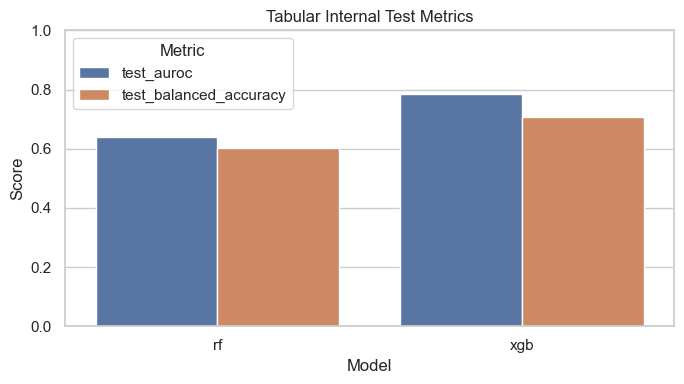

In [6]:
plot_df = summary.melt(
    id_vars='model',
    value_vars=['test_auroc', 'test_balanced_accuracy'],
    var_name='metric',
    value_name='value',
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=plot_df, x='model', y='value', hue='metric', ax=ax)
ax.set_ylim(0, 1)
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Tabular Internal Test Metrics')
ax.legend(title='Metric')
plt.tight_layout()

## Per-Drug Metrics

In [7]:
top_cols = [
    'model',
    'drug',
    'n_test',
    'n_pos',
    'n_neg',
    'auroc',
    'balanced_accuracy',
    'sensitivity',
    'specificity',
]

display(
    per_drug[[col for col in top_cols if col in per_drug.columns]]
    .sort_values(['model', 'n_test'], ascending=[True, False])
    .head(30)
)

,model,drug,n_test,n_pos,n_neg,auroc,balanced_accuracy,sensitivity,specificity
61,rf,Imatinib,204,6,198,0.487374,0.510101,0.166667,0.853535
142,rf,Trametinib (GSK1120212),202,89,113,0.652580,0.620414,0.550562,0.690265
36,rf,Dasatinib,200,35,165,0.575065,0.527273,0.600000,0.454545
88,rf,Midostaurin,195,16,179,0.522870,0.518331,0.187500,0.849162
135,rf,Sunitinib,195,11,184,0.736166,0.696640,0.545455,0.847826
133,rf,Sorafenib,193,9,184,0.752415,0.682669,0.555556,0.809783
59,rf,Ibrutinib (PCI-32765),188,18,170,0.513725,0.465686,0.166667,0.764706
148,rf,Venetoclax,187,63,124,0.664427,0.617256,0.460317,0.774194
1,rf,A-674563,180,44,136,0.639455,0.637032,0.568182,0.705882
11,rf,Afatinib (BIBW-2992),180,18,162,0.558471,0.478395,0.000000,0.956790


## KTSP-Compatible Drug Subset

In [8]:
ktsp['ktsp_eligible'] = ktsp['ktsp_eligible'].astype(bool)
eligible = ktsp[ktsp['ktsp_eligible']].copy()

display(
    eligible[[col for col in top_cols if col in eligible.columns]]
    .sort_values(['model', 'balanced_accuracy'], ascending=[True, False])
)

eligible_summary = (
    eligible.groupby('model')
    .agg(
        n_drugs=('drug', 'nunique'),
        mean_auroc=('auroc', 'mean'),
        mean_balanced_accuracy=('balanced_accuracy', 'mean'),
        mean_sensitivity=('sensitivity', 'mean'),
        mean_specificity=('specificity', 'mean'),
    )
    .reset_index()
)
display(eligible_summary)

,model,drug,n_test,auroc,balanced_accuracy,sensitivity,specificity
126,rf,Rapamycin,168,0.598242,0.637500,0.650000,0.625000
1,rf,A-674563,180,0.639455,0.637032,0.568182,0.705882
153,rf,Trametinib (GSK1120212),202,0.652580,0.620414,0.550562,0.690265
159,rf,Venetoclax,187,0.664427,0.617256,0.460317,0.774194
120,rf,Quizartinib (AC220),175,0.636067,0.606061,0.545455,0.666667
...,...,...,...,...,...,...,...
192,xgb,Bortezomib (Velcade),180,0.509173,0.483921,0.484848,0.482993
205,xgb,Doramapimod (BIRB 796),176,0.492751,0.480116,0.558824,0.401408
226,xgb,INK-128,177,0.504221,0.476558,0.883117,0.070000
231,xgb,JAK Inhibitor I,170,0.467663,0.468643,0.153846,0.783439


,model,n_drugs,mean_auroc,mean_balanced_accuracy,mean_sensitivity,mean_specificity
0,rf,37,0.553056,0.528541,0.364158,0.692924
1,xgb,37,0.549789,0.527205,0.624084,0.430326


## Output Files To Check

- `outputs/tables/tabular_internal/summary.csv`
- `outputs/tables/tabular_internal/per_drug_metrics.csv`
- `outputs/tables/tabular_internal/ktsp_compatible_metrics.csv`
- `outputs/tables/tabular_internal/predictions.csv`